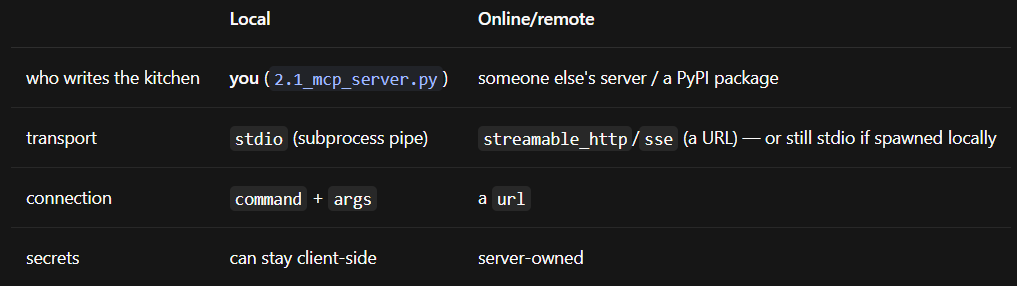

In [5]:
from dotenv import load_dotenv

load_dotenv()

True

## Local MCP server

#### Creating the client's MCP server and linking it with the server

In [6]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient(
    {
        "local_server": {
                "transport": "stdio",
                "command": "uv",
                "args": ["run", "python", "/home/im_ane/lca-lc-foundations/notebooks/module-2/resources/2.1_mcp_server.py"],
            }
    }
)

#### The client's server get infos from the server (tools , ressources, prompt)

In [7]:
# get tools
tools = await client.get_tools()

# get resources
resources = await client.get_resources("local_server")

# get prompts
prompt = await client.get_prompt("local_server", "prompt")
prompt = prompt[0].content

C'est comme commander un plat par son nom au menu : tu ne cuisines pas, tu dis le nom — c'est la cuisine (le serveur) qui exécute la recette prompt() et te la ramène.  
 
Même mécanique pour les outils : quand le modèle appelle search_web("..."), c'est le serveur qui exécute def search_web(...). La chaîne "prompt" / "search_web" est juste le nom — elle désigne la fonction à exécuter de l'autre côté du pipe.  

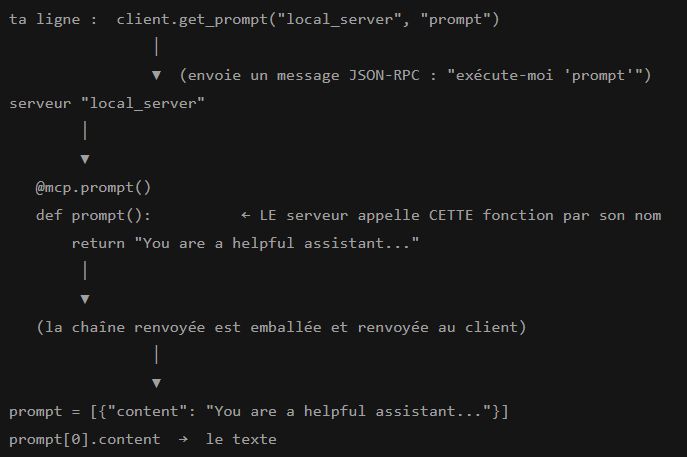

#### Create the agent 

In [10]:
from langchain.chat_models import init_chat_model
import os

model = init_chat_model(
    model="gemini-3.1-flash-lite",
    model_provider="google-genai",
    api_key=os.getenv("GOOGLE_API_KEY"),
)

In [11]:
from langchain.agents import create_agent

agent = create_agent(
    model= model,
    tools=tools,
    system_prompt=prompt
)

#### Create the human message prompt

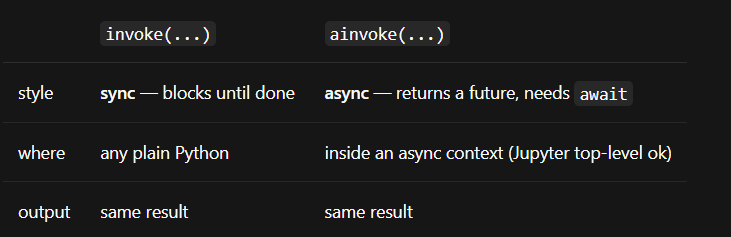

**In MCP you must use the async family because the client (get_tools, ainvoke) is async — network + subprocess under the hood.**

In [12]:
from langchain.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}

response = await agent.ainvoke(
    {"messages": [HumanMessage(content="Tell me about the langchain-mcp-adapters library")]},
    config=config
)

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [13]:
from pprint import pprint

pprint(response)

{'messages': [HumanMessage(content='Tell me about the langchain-mcp-adapters library', additional_kwargs={}, response_metadata={}, id='e2f20022-0ebd-4dc9-951e-e2a45ec20ec1'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'search_web', 'arguments': '{"query": "what is langchain-mcp-adapters"}'}, '__gemini_function_call_thought_signatures__': {'call_243258': 'EnEKbwFpFH0TSYn0yTVIOhiJiPIqhz5GhvdBxTvKZ1FrjlW3qaYk7rvgOynRIkEpFOxYWqMbo7WW6x/B2gDYwuStFPYvjP8w7YpnIKyzTh4ry/i4no44a7YDBkvMsvnkroQqmlPLN6YtRg7ESLlJyuVg0A=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0c68a-eaa0-7a83-b52d-e19506075ddf-0', tool_calls=[{'name': 'search_web', 'args': {'query': 'what is langchain-mcp-adapters'}, 'id': 'call_243258', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 199, 'output_tokens': 23, 'total_tokens': 222, 'input_token_deta

## Online MCP

In [14]:
client = MultiServerMCPClient(
    {
        "time": {
            "transport": "stdio",
            "command": "uv",
            "args": [
                "run",
                "python",
                "-m",
                "mcp_server_time",
                "--local-timezone=America/New_York"
            ]
        }
    }
)

tools = await client.get_tools()

In [16]:
agent = create_agent(
    model=model,
    tools=tools,
)

In [17]:
question = HumanMessage(content="What time is it?")

response = await agent.ainvoke(
    {"messages": [question]}
)

pprint(response)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='What time is it?', additional_kwargs={}, response_metadata={}, id='299d911b-a5b2-48e6-8c2d-b97339d30064'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_current_time', 'arguments': '{"timezone": "America/New_York"}'}, '__gemini_function_call_thought_signatures__': {'call_222154': 'EnEKbwFpFH0T3zXjkeMbIz7HNtbxc/E6JzVHdVTZUbSpbpXG8ntfJWJ0yTJQspSXqUUmtmlvCwm8sKgn4I/u3Q310+KDKdXHNYwW1bxexoeS4WBCCMm4VT/w+vWfbwrVuY0NFudnI5/MI+ll5+fEvwqjHw=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0c68d-f981-70d3-8c86-7ebfff2d14d0-0', tool_calls=[{'name': 'get_current_time', 'args': {'timezone': 'America/New_York'}, 'id': 'call_222154', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 284, 'output_tokens': 22, 'total_tokens': 306, 'input_token_details': {'cache_read': 0}}),
              T

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


**after get_tools(), LangChain converts the MCP tools into normal LangChain tools — so by the time create_agent sees them, they look like the agent's own tools. But their real home is still the server: when the model calls search_web, the client relays the call over the pipe and the server executes it (with its own secrets) before returning the result. Agent borrows, server owns.**